In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("application_train.csv")

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 307511
Columns: 122


In [5]:
df.shape

(307511, 122)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB


In [7]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [10]:
df["TARGET"].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

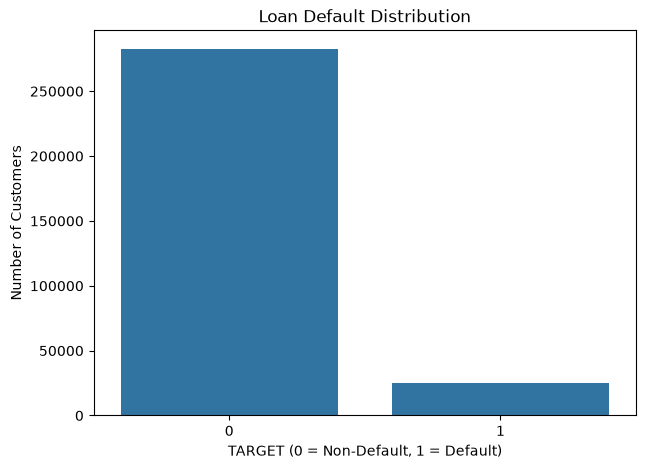

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="TARGET")

plt.title("Loan Default Distribution")
plt.xlabel("TARGET (0 = Non-Default, 1 = Default)")
plt.ylabel("Number of Customers")

plt.show()

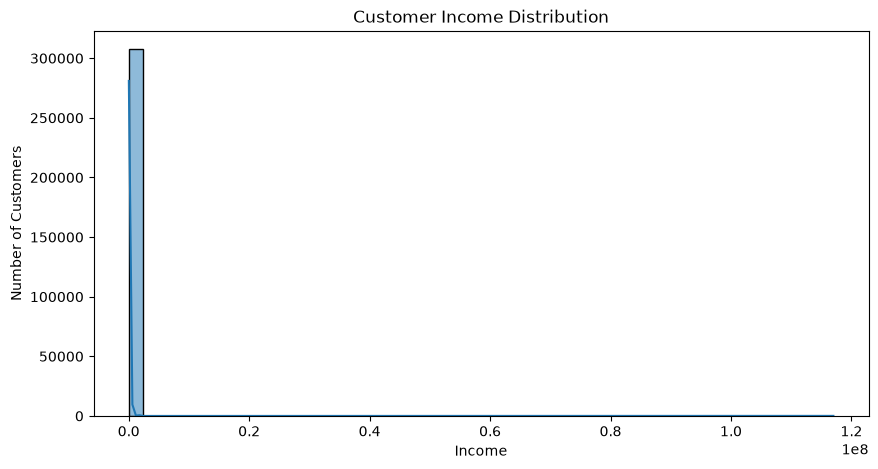

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["AMT_INCOME_TOTAL"],
    bins=50,
    kde=True
)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

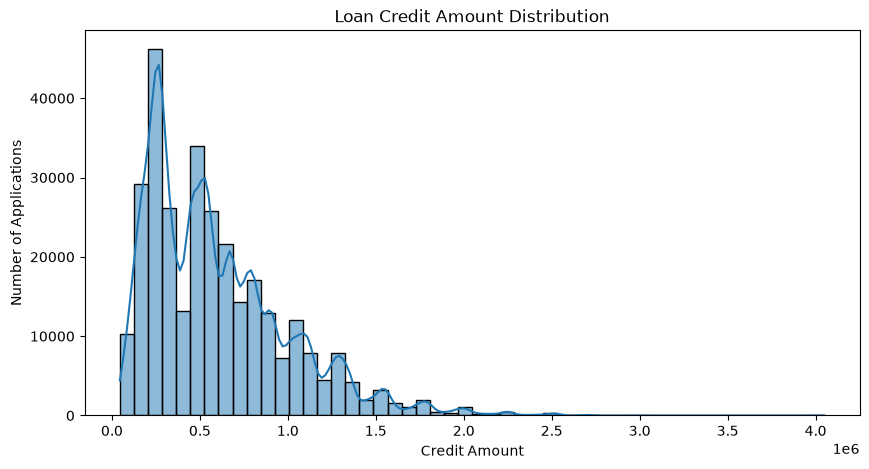

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["AMT_CREDIT"],
    bins=50,
    kde=True
)

plt.title("Loan Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Number of Applications")

plt.show()

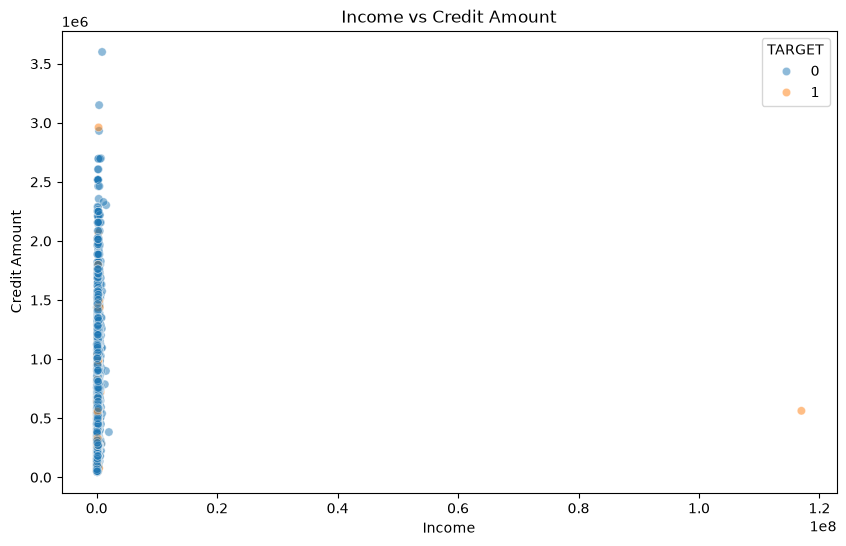

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(10000, random_state=42),
    x="AMT_INCOME_TOTAL",
    y="AMT_CREDIT",
    hue="TARGET",
    alpha=0.5
)

plt.title("Income vs Credit Amount")
plt.xlabel("Income")
plt.ylabel("Credit Amount")

plt.show()

In [15]:
summary = {
    "Total Applications": len(df),
    "Total Features": df.shape[1],
    "Defaults": df["TARGET"].sum(),
    "Non-Defaults": (df["TARGET"] == 0).sum(),
    "Default Rate": df["TARGET"].mean() * 100,
    "Average Income": df["AMT_INCOME_TOTAL"].mean(),
    "Average Credit": df["AMT_CREDIT"].mean()
}

summary

{'Total Applications': 307511,
 'Total Features': 122,
 'Defaults': np.int64(24825),
 'Non-Defaults': np.int64(282686),
 'Default Rate': np.float64(8.072881945686495),
 'Average Income': np.float64(168797.9192969845),
 'Average Credit': np.float64(599025.9997057016)}

### Handling missing values

In [16]:
missing = df.isnull().sum().sort_values(
    ascending=False
)

missing[missing > 0].head(30)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
FLOORSMIN_AVG               208642
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_MEDI            204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
LANDAREA_AVG                182590
BASEMENTAREA_MEDI           179943
BASEMENTAREA_AVG            179943
BASEMENTAREA_MODE           179943
EXT_SOURCE_1                173378
NONLIVINGAREA_MODE          169682
NONLIVINGAREA_AVG           169682
NONLIVINGAREA_MEDI          169682
ELEVATORS_MEDI              163891
ELEVATORS_AVG       

In [17]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0].head(30)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
BASEMENTAREA_MODE           58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG           55.179164
NONLIVINGARE

In [18]:
df_clean = df.copy()

In [19]:
numeric_cols = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:", len(numeric_cols))

Numerical columns: 106


In [21]:
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

In [20]:
categorical_cols = df_clean.select_dtypes(
    include=["object"]
).columns

print("Categorical columns:", len(categorical_cols))

Categorical columns: 16


C:\Users\DELL\AppData\Local\Temp\ipykernel_13736\1241025936.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(


In [22]:
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].mode()[0]
    )

In [23]:
print(
    "Remaining missing values:",
    df_clean.isnull().sum().sum()
)

Remaining missing values: 0


### OUTLIER HANDLING

In [24]:
outlier_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

In [25]:
def cap_outliers_iqr(data, columns):
    data = data.copy()

    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        data[col] = data[col].clip(
            lower=lower_bound,
            upper=upper_bound
        )

    return data

In [26]:
df_clean = cap_outliers_iqr(
    df_clean,
    outlier_cols
)

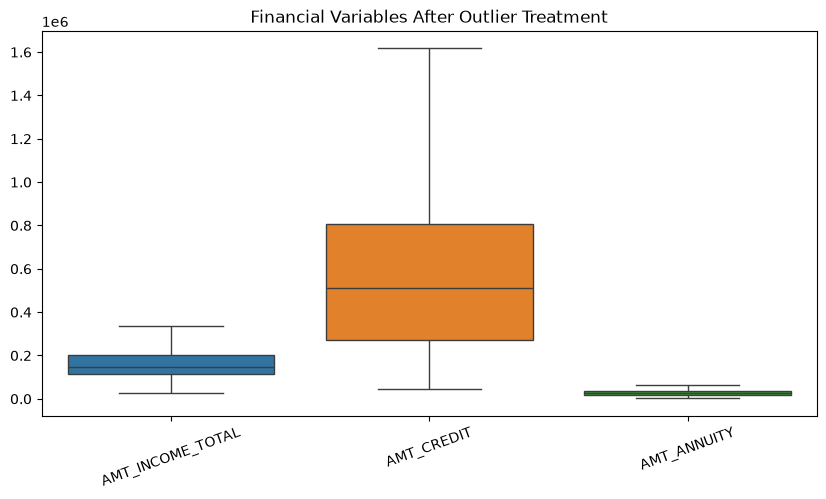

In [27]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_clean[
        [
            "AMT_INCOME_TOTAL",
            "AMT_CREDIT",
            "AMT_ANNUITY"
        ]
    ]
)

plt.title("Financial Variables After Outlier Treatment")

plt.xticks(rotation=20)

plt.show()

### FEATURE ENGINEERING

In [28]:
df_fe = df_clean.copy()

In [29]:
df_fe = df_fe.loc[
    :,
    ~df_fe.columns.duplicated()
].copy()

print(
    "Duplicate columns:",
    df_fe.columns.duplicated().sum()
)

Duplicate columns: 0


In [30]:
df_fe["AGE"] = (
    abs(df_fe["DAYS_BIRTH"]) / 365
)

In [31]:
df_fe["EMPLOYMENT_YEARS"] = (
    abs(df_fe["DAYS_EMPLOYED"]) / 365
)

In [32]:
df_fe["CREDIT_INCOME_RATIO"] = (
    df_fe["AMT_CREDIT"] /
    df_fe["AMT_INCOME_TOTAL"].replace(0, np.nan)
)

In [33]:
df_fe["ANNUITY_INCOME_RATIO"] = (
    df_fe["AMT_ANNUITY"] /
    df_fe["AMT_INCOME_TOTAL"].replace(0, np.nan)
)

In [34]:
df_fe["CREDIT_ANNUITY_RATIO"] = (
    df_fe["AMT_CREDIT"] /
    df_fe["AMT_ANNUITY"].replace(0, np.nan)
)

In [35]:
df_fe["INCOME_PER_FAMILY_MEMBER"] = (
    df_fe["AMT_INCOME_TOTAL"] /
    df_fe["CNT_FAM_MEMBERS"].replace(0, np.nan)
)

In [36]:
df_fe["INCOME_PER_CHILD"] = (
    df_fe["AMT_INCOME_TOTAL"] /
    (df_fe["CNT_CHILDREN"] + 1)
)

In [37]:
df_fe["EXT_SOURCE_AVG"] = df_fe[
    [
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]
].mean(axis=1)

In [38]:
df_fe["EXT_SOURCE_SUM"] = df_fe[
    [
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]
].sum(axis=1)

In [39]:
engineered_features = [
    "AGE",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",
    "INCOME_PER_FAMILY_MEMBER",
    "INCOME_PER_CHILD",
    "EXT_SOURCE_AVG",
    "EXT_SOURCE_SUM"
]

df_fe[engineered_features].head()

,AGE,EMPLOYMENT_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,INCOME_PER_FAMILY_MEMBER,INCOME_PER_CHILD,EXT_SOURCE_AVG,EXT_SOURCE_SUM
0,25.920548,1.745205,2.007889,0.121978,16.461104,202500.0,202500.0,0.161787,0.485361
1,45.931507,3.254795,4.790750,0.132217,36.234085,135000.0,270000.0,0.489596,1.468789
2,52.180822,0.616438,2.000000,0.100000,20.000000,67500.0,67500.0,0.597159,1.791477
3,52.068493,8.326027,2.316167,0.219900,10.532818,67500.0,135000.0,0.563905,1.691716
4,54.608219,8.323288,4.222222,0.179963,23.461618,121500.0,121500.0,0.454671,1.364012


In [40]:
for col in engineered_features:
    if df_fe[col].isnull().sum() > 0:
        df_fe[col] = df_fe[col].fillna(
            df_fe[col].median()
        )

In [41]:
print(
    "Missing values:",
    df_fe[engineered_features].isnull().sum().sum()
)

Missing values: 0


### building a model

In [42]:
features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "AGE",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",
    "INCOME_PER_FAMILY_MEMBER",
    "INCOME_PER_CHILD",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "REGION_POPULATION_RELATIVE",
    "DAYS_ID_PUBLISH",
    "DAYS_REGISTRATION",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_AVG",
    "EXT_SOURCE_SUM"
]

In [43]:
X = df_fe[features].copy()
y = df_fe["TARGET"].copy()

In [46]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print(
    "Duplicate columns:",
    X.columns.duplicated().sum()
)

print(
    "Missing values:",
    X.isnull().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(X).sum().sum()
)

X shape: (307511, 21)
y shape: (307511,)
Duplicate columns: 0
Missing values: 0
Infinite values: 0


### split the data

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (246008, 21)
Testing: (61503, 21)


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [51]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [75]:
lr_pred = logistic_model.predict(
    X_test_scaled
)

lr_probability = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred
)

lr_recall = recall_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred
)

lr_roc_auc = roc_auc_score(
    y_test,
    lr_probability
)

print("Logistic Regression")
print("-------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_roc_auc)

Logistic Regression
-------------------------
Accuracy : 0.6794953091719104
Precision: 0.1530933897906375
Recall   : 0.6553877139979859
F1 Score : 0.24820747520976355
ROC-AUC  : 0.728788070670647


In [77]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.68      0.80     56538
           1       0.15      0.66      0.25      4965

    accuracy                           0.68     61503
   macro avg       0.56      0.67      0.52     61503
weighted avg       0.89      0.68      0.75     61503



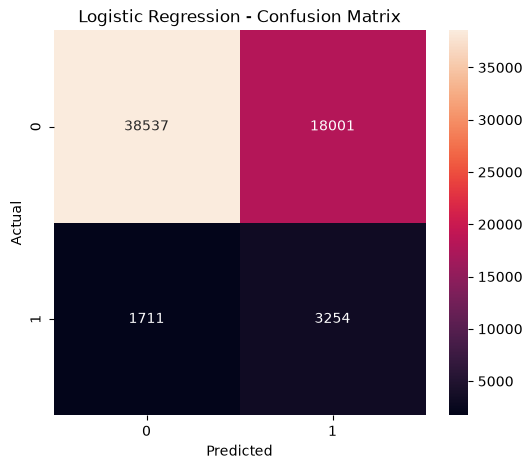

In [78]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d"
)

plt.title(
    "Logistic Regression - Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

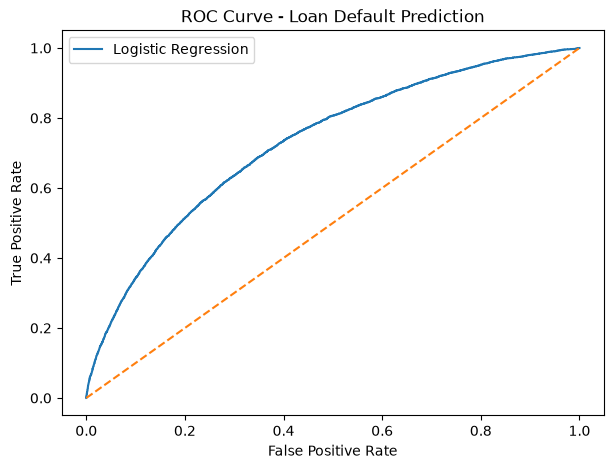

In [79]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    lr_probability
)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label="Logistic Regression")

plt.plot([0, 1],[0, 1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Loan Default Prediction")

plt.legend()

plt.show()

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [57]:
rf_pred = rf_model.predict(X_test)

rf_probability = rf_model.predict_proba(X_test)[:, 1]

In [70]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probability
)

print("Random Forest")
print("-------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest
-------------------------
Accuracy : 0.7059493032860186
Precision: 0.16379663796637967
Recall   : 0.6437059415911379
F1 Score : 0.26114311394370227
ROC-AUC  : 0.7410130526690477


In [80]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.16      0.64      0.26      4965

    accuracy                           0.71     61503
   macro avg       0.56      0.68      0.54     61503
weighted avg       0.89      0.71      0.77     61503



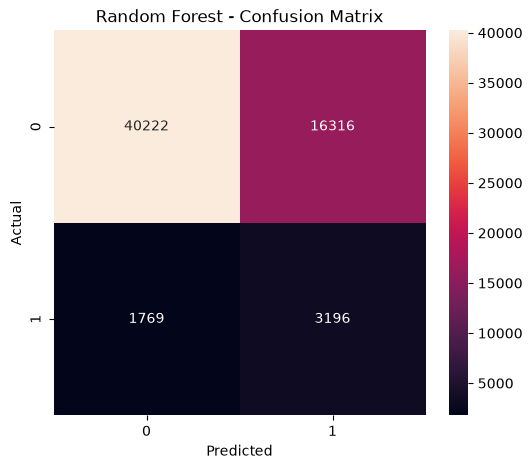

In [81]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d"
)

plt.title(
    "Random Forest - Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [83]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(
    ascending=False
)

rf_importance.head(15)

EXT_SOURCE_AVG          0.226810
EXT_SOURCE_SUM          0.222662
EXT_SOURCE_3            0.103696
EXT_SOURCE_2            0.100299
EMPLOYMENT_YEARS        0.047787
EXT_SOURCE_1            0.046705
CREDIT_ANNUITY_RATIO    0.039935
AGE                     0.033704
AMT_GOODS_PRICE         0.022663
AMT_ANNUITY             0.022110
DAYS_ID_PUBLISH         0.020150
AMT_CREDIT              0.019784
ANNUITY_INCOME_RATIO    0.018540
CREDIT_INCOME_RATIO     0.017029
DAYS_REGISTRATION       0.014706
dtype: float64

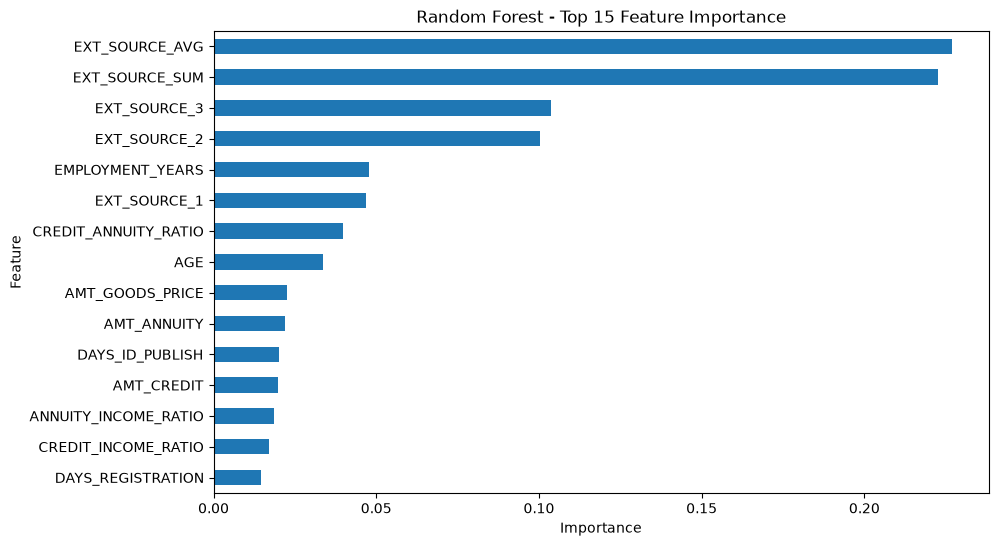

In [84]:
plt.figure(figsize=(10, 6))

rf_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "Random Forest - Top 15 Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [62]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 3.2 MB/s eta 0:00:16
   - -------------------------------------- 1.6/48.9 MB 2.9 MB/s eta 0:00:17
   - -------------------------------------- 1.8/48.9 MB 2.4 MB/s eta 0:00:20
   - -------------------------------------- 2.1/48.9 MB 2.4 MB/s eta 0:00:20
   -- ------------------------------------- 2.6/48.9 MB 2.3 MB/s eta 0:00:21
   -- ------------------------------------- 3.1/48.9 MB 2.2 MB/s eta 0:00:22
   -- ------------------------------------- 3.1/48.9 MB 2.2 MB/s eta 0:00:22
   -- ------------------------------------- 3.1/48.9 MB 2.2 MB/s eta 0:00:22
   -- ------------------------------------- 3.4/48.9 MB 1.6 MB/s eta 0:00:30
   --- ------------------------------------ 3.9/48.9 MB 1.7 MB/s eta 0:00:27
   ---- ----

In [63]:
from xgboost import XGBClassifier

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(
    "scale_pos_weight:",
    scale_pos_weight
)

scale_pos_weight: 11.38710976837865


In [64]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [65]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [66]:
xgb_pred = xgb_model.predict(
    X_test
)

xgb_probability = xgb_model.predict_proba(
    X_test
)[:, 1]

print("XGBoost predictions completed!")

XGBoost predictions completed!


In [67]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_probability
)

print("XGBoost")
print("-------------------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)

XGBoost
-------------------------
Accuracy : 0.7078841682519552
Precision: 0.16933719924716414
Recall   : 0.6704934541792548
F1 Score : 0.2703866146848603
ROC-AUC  : 0.7604105030804439


In [82]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.71      0.77     61503



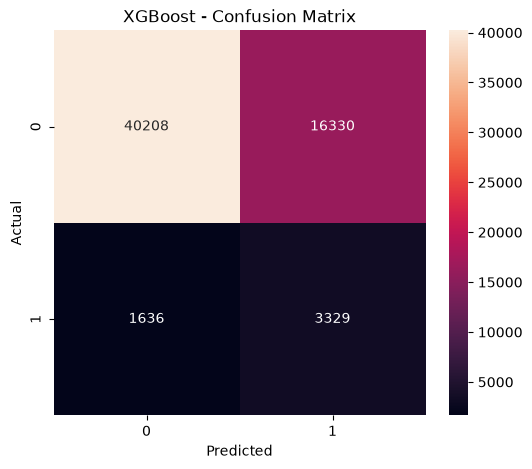

In [69]:
cm_xgb = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d"
)

plt.title(
    "XGBoost - Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [85]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(
    ascending=False
)

xgb_importance.head(15)

EXT_SOURCE_SUM          0.362632
EXT_SOURCE_AVG          0.220246
CREDIT_ANNUITY_RATIO    0.037912
EMPLOYMENT_YEARS        0.035497
AMT_GOODS_PRICE         0.030130
EXT_SOURCE_1            0.029104
AMT_CREDIT              0.027470
EXT_SOURCE_3            0.025439
AMT_ANNUITY             0.024103
AGE                     0.022338
ANNUITY_INCOME_RATIO    0.020620
EXT_SOURCE_2            0.018794
DAYS_ID_PUBLISH         0.018294
CREDIT_INCOME_RATIO     0.018141
CNT_FAM_MEMBERS         0.016837
dtype: float32

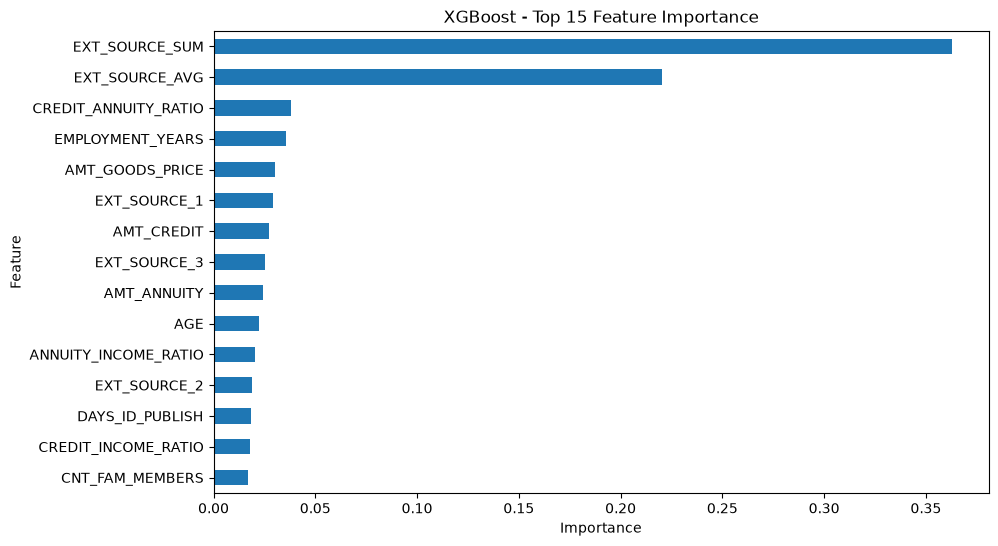

In [86]:
plt.figure(figsize=(10, 6))

xgb_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "XGBoost - Top 15 Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [87]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],
    
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],
    
    "F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ],
    
    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.679495,0.153093,0.655388,0.248207,0.728788
1,Random Forest,0.705949,0.163797,0.643706,0.261143,0.741013
2,XGBoost,0.707884,0.169337,0.670493,0.270387,0.760411


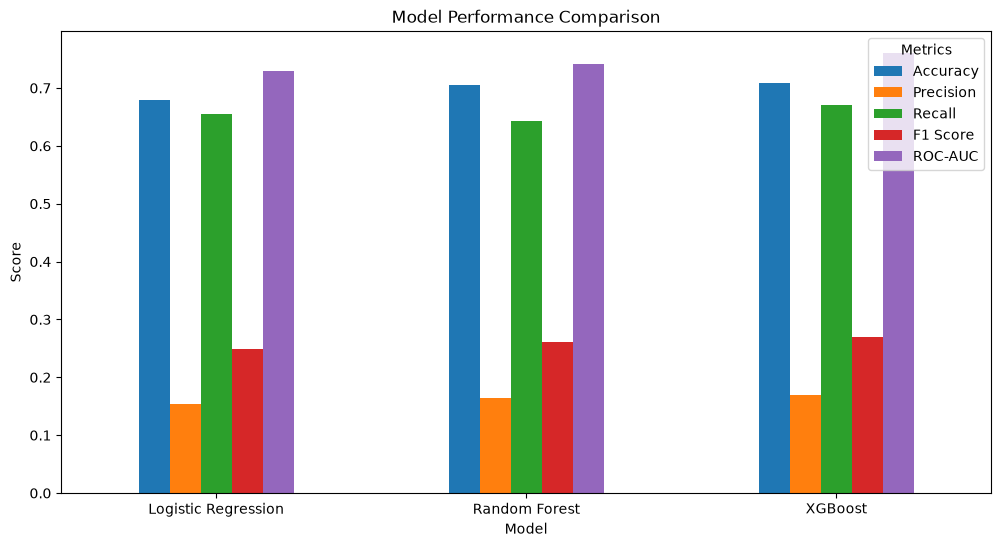

In [88]:
results.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(rotation=0)
plt.legend(
    title="Metrics"
)

plt.show()

In [91]:
df_fe.to_csv(
    "application_train_feature_engineered.csv",
    index=False
)

print("Feature-engineered dataset saved successfully!")

Feature-engineered dataset saved successfully!


In [90]:
df_clean.to_csv(
    "application_train_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [92]:
import os

print(
    "Cleaned file:",
    os.path.abspath("application_train_cleaned.csv")
)

print(
    "Feature-engineered file:",
    os.path.abspath(
        "application_train_feature_engineered.csv"
    )
)

Cleaned file: C:\Users\DELL\Downloads\Bank_loan\application_train_cleaned.csv
Feature-engineered file: C:\Users\DELL\Downloads\Bank_loan\application_train_feature_engineered.csv


In [ ]:
MySQL@12345